c:\Users\hisj0\.conda\envs\DL\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\hisj0\.conda\envs\DL\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


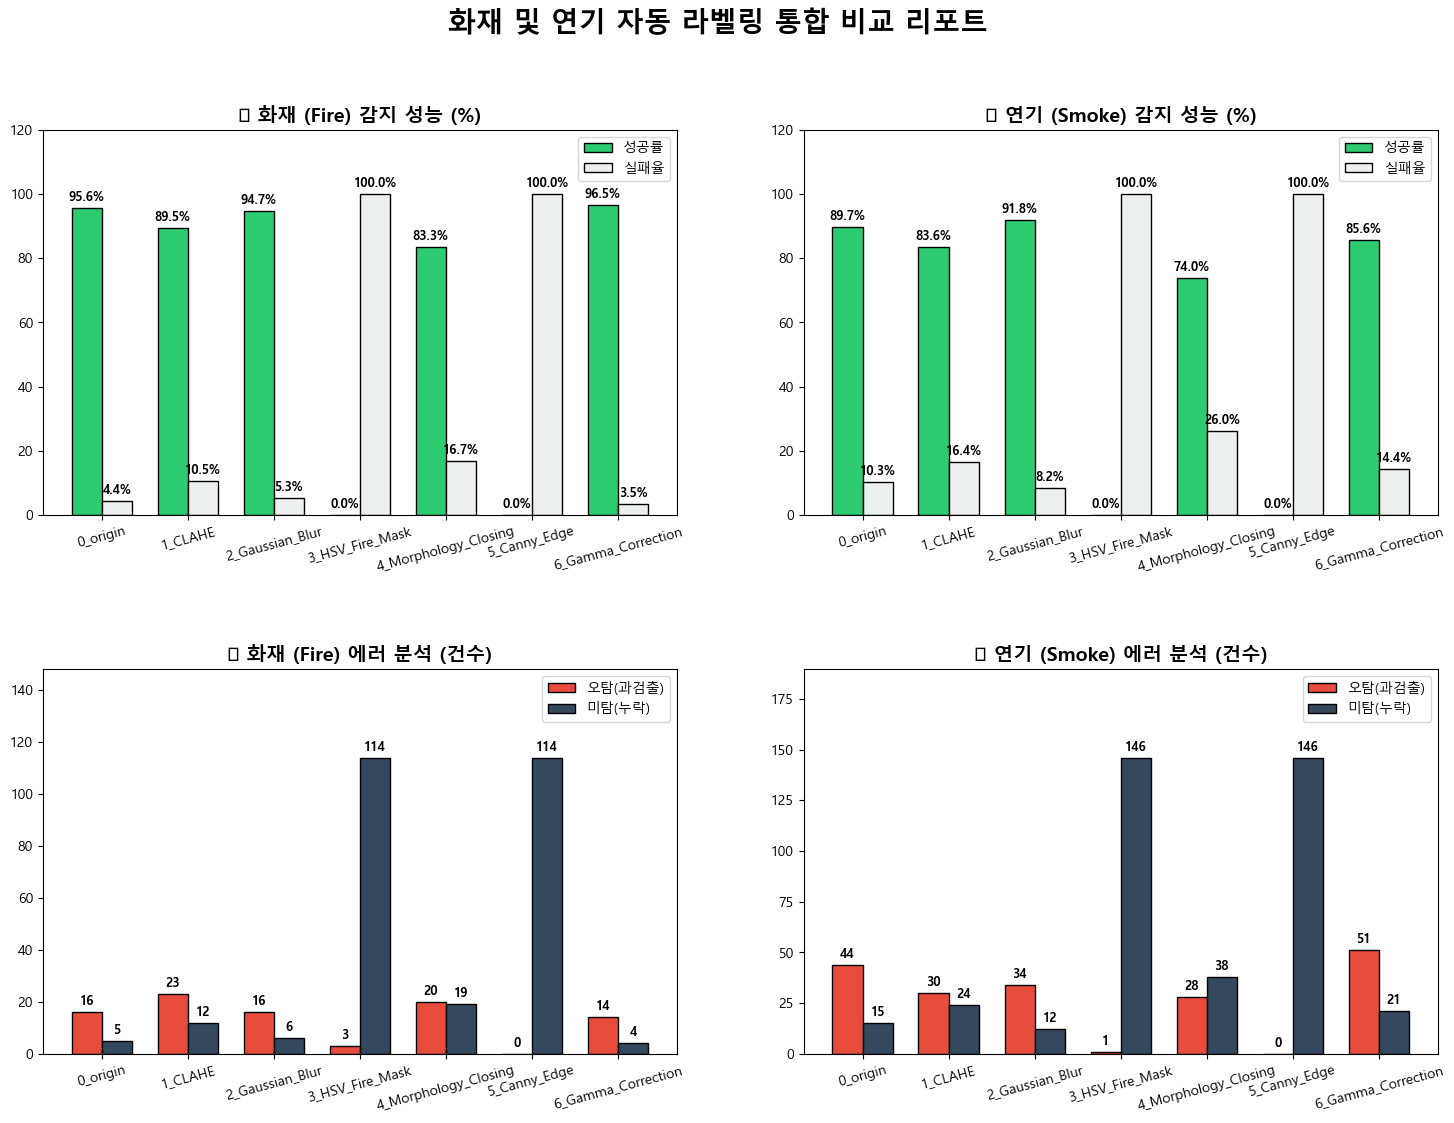

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog, messagebox
from matplotlib import font_manager, rc

# ==========================================
# 0. 한글 폰트 설정
# ==========================================
try:
    if os.name == 'nt':
        font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
        rc('font', family=font_name)
    else:
        rc('font', family='AppleGothic')
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

def select_directories():
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    messagebox.showinfo("안내", "1. 정답(GT) 폴더를 선택하세요.")
    gt_dir = filedialog.askdirectory(title="정답 폴더 선택")
    messagebox.showinfo("안내", "2. 자동 라벨 폴더들이 포함된 최상위 루트 폴더를 선택하세요.")
    root_pred_dir = filedialog.askdirectory(title="자동 라벨 루트 폴더 선택")
    return gt_dir, root_pred_dir

def get_label_data(file_path):
    data = []
    if os.path.exists(file_path):
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        data.append({'cls': int(parts[0]), 'bbox': [float(p) for p in parts[1:5]]})
        except: pass
    return data

def calculate_iou(box1, box2):
    b1_x1, b1_y1 = box1[0] - box1[2]/2, box1[1] - box1[3]/2
    b1_x2, b1_y2 = box1[0] + box1[2]/2, box1[1] + box1[3]/2
    b2_x1, b2_y1 = box2[0] - box2[2]/2, box2[1] - box2[3]/2
    b2_x2, b2_y2 = box2[0] + box2[2]/2, box2[1] + box2[3]/2
    ix1, iy1 = max(b1_x1, b2_x1), max(b1_y1, b2_y1)
    ix2, iy2 = min(b1_x2, b2_x2), min(b1_y2, b2_y2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    ia = iw * ih
    ua = (box1[2] * box1[3]) + (box2[2] * box2[3]) - ia
    return ia / (ua + 1e-6)

def run_final_analysis():
    GT_DIR, ROOT_PRED_DIR = select_directories()
    if not GT_DIR or not ROOT_PRED_DIR: return

    # 1. 'labels' 폴더 탐색 (최대 7개)
    found_labels = []
    for root, dirs, files in os.walk(ROOT_PRED_DIR):
        if os.path.basename(root).lower() == 'labels':
            parent_name = os.path.basename(os.path.dirname(root))
            found_labels.append((root, parent_name))
            if len(found_labels) == 7: break

    if not found_labels:
        messagebox.showwarning("알림", "'labels' 폴더를 찾지 못했습니다.")
        return

    # 2. 통계 계산
    gt_files = [f for f in os.listdir(GT_DIR) if f.endswith('.txt')]
    all_results = []

    for label_path, title in found_labels:
        f_stat = {0: {'tp': 0, 'fp': 0, 'fn': 0, 'total': 0}, 1: {'tp': 0, 'fp': 0, 'fn': 0, 'total': 0}}
        for fname in gt_files:
            gts = get_label_data(os.path.join(GT_DIR, fname))
            preds = get_label_data(os.path.join(label_path, fname))
            for c in [0, 1]:
                c_gts = [d['bbox'] for d in gts if d['cls'] == c]
                c_preds = [d['bbox'] for d in preds if d['cls'] == c]
                f_stat[c]['total'] += len(c_gts)
                matched = [False] * len(c_gts)
                for pb in c_preds:
                    best_iou, bi = 0, -1
                    for i, gb in enumerate(c_gts):
                        if not matched[i]:
                            iou = calculate_iou(gb, pb)
                            if iou > best_iou: best_iou, bi = iou, i
                    if best_iou >= 0.5:
                        f_stat[c]['tp'] += 1
                        matched[bi] = True
                    else: f_stat[c]['fp'] += 1
                f_stat[c]['fn'] += matched.count(False)
        all_results.append((title, f_stat))

    # 3. 그래프 그리기 (2x2 구성)
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.2)
    
    titles = [res[0] for res in all_results]
    x = np.arange(len(titles))
    width = 0.35

    def add_labels(ax, bars, is_percent=False):
        """막대 위에 수치를 표시하는 함수"""
        for bar in bars:
            height = bar.get_height()
            label = f'{height:.1f}%' if is_percent else f'{int(height)}'
            ax.annotate(label,
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3포인트 위로 띄움
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    for c, c_name in zip([0, 1], ['화재 (Fire)', '연기 (Smoke)']):
        # --- 상단: 성공/실패율 (%) ---
        recalls = [(res[1][c]['tp']/res[1][c]['total']*100 if res[1][c]['total']>0 else 0) for res in all_results]
        fails = [100 - r for r in recalls]

        b1 = axes[0, c].bar(x - width/2, recalls, width, label='성공률', color='#2ecc71', edgecolor='black')
        b2 = axes[0, c].bar(x + width/2, fails, width, label='실패율', color='#ecf0f1', edgecolor='black')
        
        axes[0, c].set_title(f'✅ {c_name} 감지 성능 (%)', fontsize=14, fontweight='bold')
        axes[0, c].set_xticks(x)
        axes[0, c].set_xticklabels(titles, rotation=15)
        axes[0, c].set_ylim(0, 120)
        axes[0, c].legend()
        add_labels(axes[0, c], b1, True)
        add_labels(axes[0, c], b2, True)

        # --- 하단: 에러 건수 (Count) ---
        fp = [res[1][c]['fp'] for res in all_results]
        fn = [res[1][c]['fn'] for res in all_results]

        b3 = axes[1, c].bar(x - width/2, fp, width, label='오탐(과검출)', color='#e74c3c', edgecolor='black')
        b4 = axes[1, c].bar(x + width/2, fn, width, label='미탐(누락)', color='#34495e', edgecolor='black')
        
        axes[1, c].set_title(f'❌ {c_name} 에러 분석 (건수)', fontsize=14, fontweight='bold')
        axes[1, c].set_xticks(x)
        axes[1, c].set_xticklabels(titles, rotation=15)
        
        max_val = max(max(fp), max(fn), 5)
        axes[1, c].set_ylim(0, max_val * 1.3)
        axes[1, c].legend()
        add_labels(axes[1, c], b3, False)
        add_labels(axes[1, c], b4, False)

    plt.suptitle("화재 및 연기 자동 라벨링 통합 비교 리포트", fontsize=20, fontweight='bold', y=0.98)
    plt.show()

if __name__ == "__main__":
    run_final_analysis()